# **Info**

# **Project Objectives**
* Twitter Data Processing
* Sentiment Analysis
* Retweet Network Analysis
* Tweet Map Visualization

# **Setup**

In [8]:
import pandas as pd 
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# **Data Import**

## **Retweet Data**

In [3]:
sotu_retweets = pd.read_csv('Input Data/sotu2018-rt.csv')

print(sotu_retweets.shape)
print(sotu_retweets.columns)
print(sotu_retweets.head())

(2340, 37)
Index(['contributors', 'coordinates', 'created_at', 'extended_entities',
       'favorite_count', 'favorited', 'filter_level', 'geo', 'id', 'id_str',
       'in_reply_to_screen_name', 'in_reply_to_status_id',
       'in_reply_to_status_id_str', 'in_reply_to_user_id',
       'in_reply_to_user_id_str', 'is_quote_status', 'lang', 'place',
       'possibly_sensitive', 'quote_count',
       'quoted_status-extended_tweet-full_text', 'quoted_status-text',
       'quoted_status-user-screen_name', 'quoted_status_id',
       'quoted_status_id_str', 'reply_count', 'retweet_count', 'retweeted',
       'retweeted_status-extended_tweet-full_text', 'retweeted_status-text',
       'retweeted_status-user-screen_name', 'source', 'text', 'timestamp_ms',
       'truncated', 'user-screen_name', 'withheld_in_countries'],
      dtype='object')
   contributors  coordinates                      created_at  \
0           NaN          NaN  Wed Jan 31 03:51:59 +0000 2018   
1           NaN          NaN

## **Reply Data**

In [5]:
sotu_replies = pd.read_csv('Input Data/sotu2018-reply.csv')

print(sotu_replies.shape)
print(sotu_replies.columns)
print(sotu_replies.head())

(2000, 36)
Index(['contributors', 'coordinates', 'created_at', 'display_text_range',
       'extended_entities', 'extended_tweet', 'extended_tweet-full_text',
       'favorite_count', 'favorited', 'filter_level', 'geo', 'id', 'id_str',
       'in_reply_to_screen_name', 'in_reply_to_status_id',
       'in_reply_to_status_id_str', 'in_reply_to_user_id',
       'in_reply_to_user_id_str', 'is_quote_status', 'lang', 'place',
       'possibly_sensitive', 'quote_count',
       'quoted_status-extended_tweet-full_text', 'quoted_status-text',
       'quoted_status-user-screen_name', 'quoted_status_id',
       'quoted_status_id_str', 'reply_count', 'retweet_count', 'retweeted',
       'source', 'text', 'timestamp_ms', 'truncated', 'user-screen_name'],
      dtype='object')
   contributors  coordinates                      created_at  \
0           NaN          NaN  Wed Jan 31 00:21:22 +0000 2018   
1           NaN          NaN  Wed Jan 31 02:42:15 +0000 2018   
2           NaN          NaN  Tue J

# **Network Creation**

## **Retweet Network**

In [11]:
# Create retweet network from edgelist
G_rt = nx.from_pandas_edgelist(
    sotu_retweets,
    source = 'user-screen_name',
    target = 'retweeted_status-user-screen_name',
    create_using = nx.DiGraph())
 
# Print the number of nodes
print('Nodes in RT network:', len(G_rt.nodes()))

# Print the number of edges
print('Edges in RT network:', len(G_rt.edges()))

# Print the number of degrees
print('Degrees in RT network:', dict(G_rt.degree()))

Nodes in RT network: 2287
Edges in RT network: 2340
Degrees in RT network: {'MatthewJAld': 1, 'ScottPresler': 68, 'broussard_sr': 1, 'RealJack': 14, 'CLSTEPHANY': 1, 'UNITEDWEDREAM': 14, 'DAWNSTUTESMAN': 1, 'TomiLahren': 45, 'SCischk': 1, 'bceil': 1, 'glennbeck': 12, 'JimJestedm': 1, 'PressSec': 8, 'CaliConsrvative': 2, 'Fuctupmind': 11, 'oilaman': 1, 'SonofLiberty357': 7, 'kimmieguy': 1, 'KamVTV': 12, 'michaelsolakiew': 1, 'atroussov': 1, 'LizCrokin': 9, 'crose84': 1, 'JoyAnnReid': 33, 'colaresisle': 2, 'krassenstein': 10, 'thedreadedaw': 4, 'TheRickyDavila': 12, 'JamesTLockhart': 1, 'Public_Citizen': 17, 'davidpsdem': 2, 'laamigable21': 2, 'GayRepublicSwag': 14, 'likessailboats': 1, 'Shakestweetz': 11, 'buckpolitics': 1, 'WaffleSundays': 1, 'DorianSoudjian': 1, 'WhiteHouse': 71, 'FightingChase': 1, 'Cernovich': 10, 'BennyHCarroll': 1, 'annespo': 2, 'jmcconnell522': 1, 'StrangeLunaMari': 1, 'michelleking66': 2, 'EARTH3R': 2, 'rychemom': 1, 'moviebill52': 1, 'KatiePavlich': 14, 'sapmcd

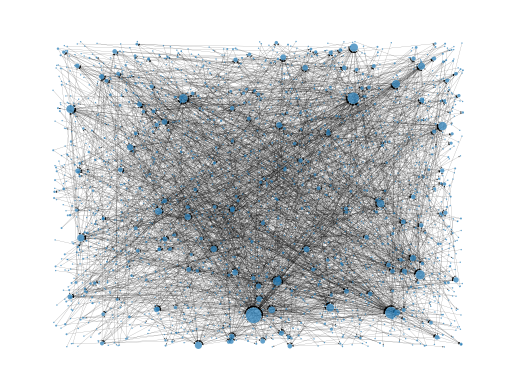

In [14]:
# Create random layout positions
pos = nx.random_layout(G_rt)

# Create size list
sizes = [x[1] for x in G_rt.degree()]

# Draw the network
nx.draw_networkx(G_rt,pos, 
    with_labels = False, 
    node_size = sizes,
    width = 0.1, alpha = 0.7,
    arrowsize = 2, linewidths = 0)

# Turn axis off and show
plt.axis('off')
plt.show()

## **Reply Network**

In [6]:
# Create reply network from edgelist
G_reply = nx.from_pandas_edgelist(
    sotu_replies,
    source = 'user-screen_name',
    target = 'in_reply_to_screen_name',
    create_using = nx.DiGraph())
    
# Print the number of nodes
print('Nodes in reply network:', len(G_reply.nodes()))

# Print the number of edges
print('Edges in reply network:', len(G_reply.edges()))

Nodes in reply network: 2622
Edges in reply network: 1904


# **Centrality**

## **In-Degree Centrality**

In [18]:
column_names = ['screen_name', 'degree_centrality']

# Generate in-degree centrality for retweets 
rt_centrality = nx.in_degree_centrality(G_rt)

# Generate in-degree centrality for replies 
reply_centrality = nx.in_degree_centrality(G_reply)

# Store centralities in DataFrame
rt = pd.DataFrame(list(rt_centrality.items()), columns = column_names)
reply = pd.DataFrame(list(reply_centrality.items()), columns = column_names)

# Print first five results in descending order of centrality
print('Retweet centrality')
display(rt.sort_values('degree_centrality', ascending = False).head())

# Print first five results in descending order of centrality
print('Reply centrality')
display(reply.sort_values('degree_centrality', ascending = False).head())

Retweet centrality


,screen_name,degree_centrality
84,FoxNews,0.055993
38,WhiteHouse,0.031059
1,ScottPresler,0.029746
7,TomiLahren,0.019685
175,HouseGOP,0.017060


Reply centrality


,screen_name,degree_centrality
51,realDonaldTrump,0.057230
53,POTUS,0.019458
22,FoxNews,0.013735
6,WhiteHouse,0.011064
416,FLOTUS,0.010301


## **Betweeness Centrality**

In [21]:
column_names = ['screen_name', 'betweenness_centrality']

# Generate betweenness centrality for retweets 
rt_centrality = nx.betweenness_centrality(G_rt)

# Generate betweenness centrality for replies 
reply_centrality = nx.betweenness_centrality(G_reply)

# Store centralities in data frames
rt = pd.DataFrame(list(rt_centrality.items()), columns = column_names )
reply = pd.DataFrame(list(reply_centrality.items()), columns = column_names )

# Print first five results in descending order of centrality
print('Retweet Betweenness Centrality')
display(rt.sort_values('betweenness_centrality', ascending = False).head())

# Print first five results in descending order of centrality
print('Reply Betweenness Centrality')
display(reply.sort_values('betweenness_centrality', ascending = False).head())

Retweet Betweenness Centrality


,screen_name,betweenness_centrality
84,FoxNews,0.000026
29,Public_Citizen,0.000009
206,ChristiChat,0.000005
119,guypbenson,0.000005
362,johncardillo,0.000004


Reply Betweenness Centrality


,screen_name,betweenness_centrality
288,ScottPresler,1.019365e-06
319,HRCNJVolunteers,2.912471e-07
1109,RRN3,2.912471e-07
1697,thebestcloser,2.912471e-07
1844,BrandonTXNeely,1.456236e-07


## **Ratios**

In [24]:
column_names = ['screen_name', 'degree']

# Calculate in-degrees and store in DataFrame
degree_rt = pd.DataFrame(list(G_rt.in_degree()), columns = column_names)
degree_reply = pd.DataFrame(list(G_reply.in_degree()), columns = column_names)

# Merge the two DataFrames on screen name
ratio = degree_rt.merge(degree_reply, on = 'screen_name', suffixes = ('_rt', '_reply'))

# Calculate the ratio
ratio['ratio'] = ratio['degree_reply'] / ratio['degree_rt']

# Exclude any tweets with less than 5 retweets
ratio = ratio[ratio['degree_rt'] >= 5]

# Print out first five with highest ratio
display(ratio.sort_values('ratio', ascending = False).head())

,screen_name,degree_rt,degree_reply,ratio
46,SpeakerRyan,8,15,1.875
53,NBCNews,20,18,0.900
43,benshapiro,5,4,0.800
42,SenateGOP,5,3,0.600
85,CBSThisMorning,6,3,0.500
